# Control Matrix Policy Analysis


In [ ]:
import os
import sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import polars as pl

RESULTS_DIR = '../Control Matrix Policy/Results'
PLOTS_DIR = './Plots'
EXPERIMENTS_PARQUET = './Results/optimisation_experiments.parquet'
BEST_POLICIES_PARQUET = './Results/optimisation_best_policies.parquet'
EQUITY_INDEX = 1  # [bonds, stocks] -> stocks

os.makedirs(PLOTS_DIR, exist_ok=True)

experiment_meta_df = pl.read_parquet(EXPERIMENTS_PARQUET)
best_policies_df = pl.read_parquet(BEST_POLICIES_PARQUET)

control_experiment_meta_df = (
    experiment_meta_df
    .filter(
        pl.col('experiment_file').str.contains(r'Control Matrix Policy[/\\]Results')
        & (pl.col('n_time_nodes') > 1)
        & (pl.col('n_wealth_nodes') > 1)
    )
    .select(['experiment_file', 'sampler', 'n_time_nodes', 'n_wealth_nodes'])
    .unique()
    .sort(['sampler', 'n_time_nodes', 'n_wealth_nodes', 'experiment_file'])
)

policy_df = (
    best_policies_df
    .join(control_experiment_meta_df, on='experiment_file', how='inner')
    .drop_nulls(['time_node', 'wealth_node', 'cash', 'bonds', 'stocks'])
)

print(
    f"Loaded {control_experiment_meta_df.height} control-matrix policy runs from parquet "
    f"({BEST_POLICIES_PARQUET})"
)

Loaded 48 control-matrix policy runs from parquet (./Results/optimisation_best_policies.parquet)


In [ ]:
from types import SimpleNamespace

def _format_money_tick(value: float) -> str:
    if value >= 1_000_000:
        return f'${value / 1_000_000:.1f}M'
    return f'${value / 1_000:.0f}k'

def _bilinear_interpolate_surface(
    surface: np.ndarray,
    x_nodes: np.ndarray,
    y_nodes: np.ndarray,
    x_target: np.ndarray,
    y_target: np.ndarray,
) -> np.ndarray:
    """Bilinearly interpolate a surface defined on (x_nodes, y_nodes)."""
    surface = np.asarray(surface, dtype=float)
    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)

    # First interpolate along wealth for each time node.
    wealth_interp = np.vstack([
        np.interp(y_target, y_nodes, surface[x_idx, :])
        for x_idx in range(len(x_nodes))
    ])

    # Then interpolate along time for each wealth location.
    out = np.zeros((len(x_target), len(y_target)), dtype=float)
    for y_idx in range(len(y_target)):
        out[:, y_idx] = np.interp(x_target, x_nodes, wealth_interp[:, y_idx])

    return out

def _surface_from_long(
    surface_df: pl.DataFrame,
    value_col: str,
    time_nodes: np.ndarray,
    wealth_nodes: np.ndarray,
    *,
    fill_value: float = np.nan,
) -> np.ndarray:
    lookup = {
        (float(t), float(w)): float(v)
        for t, w, v in surface_df.select(['time_node', 'wealth_node', value_col]).iter_rows()
    }

    out = np.full((len(time_nodes), len(wealth_nodes)), fill_value, dtype=float)
    for t_idx, time_node in enumerate(time_nodes):
        for w_idx, wealth_node in enumerate(wealth_nodes):
            maybe_value = lookup.get((float(time_node), float(wealth_node)))
            if maybe_value is not None:
                out[t_idx, w_idx] = maybe_value
    return out

INTERP_TIME_POINTS = 180
INTERP_WEALTH_POINTS = 180

if 'policy_df' not in globals():
    raise RuntimeError('Run Cell 2 first (parquet loading).')

# Build synthetic experiment payloads from parquet so downstream plotting cells remain compatible.
experiments = []
for meta_row in control_experiment_meta_df.iter_rows(named=True):
    experiment_file = meta_row['experiment_file']
    run_df = (
        policy_df
        .filter(pl.col('experiment_file') == experiment_file)
        .sort(['time_node', 'wealth_node'])
    )

    if run_df.is_empty():
        continue

    time_nodes = np.sort(run_df['time_node'].unique().to_numpy().astype(float))
    wealth_nodes = np.sort(run_df['wealth_node'].unique().to_numpy().astype(float))
    if len(time_nodes) <= 1 or len(wealth_nodes) <= 1:
        continue

    bonds_surface = _surface_from_long(run_df, 'bonds', time_nodes, wealth_nodes)
    stocks_surface = _surface_from_long(run_df, 'stocks', time_nodes, wealth_nodes)
    if np.isnan(bonds_surface).any() or np.isnan(stocks_surface).any():
        # Skip incomplete grids to avoid interpolation artifacts later.
        continue

    best_policy = np.stack([bonds_surface, stocks_surface], axis=2)
    cfg = SimpleNamespace(
        RETURN_SAMPLER=meta_row['sampler'],
        TIME_NODE_COUNT=int(meta_row['n_time_nodes']),
        WEALTH_NODE_COUNT=int(meta_row['n_wealth_nodes']),
    )
    res = SimpleNamespace(
        best_policy=best_policy,
        time_nodes=time_nodes,
        wealth_nodes=wealth_nodes,
        best_utility=np.nan,
    )
    experiments.append({'config': cfg, 'result': res})

print(f'Prepared {len(experiments)} control-matrix payloads from parquet.')

records = []
for payload in experiments:
    cfg = payload['config']
    res = payload['result']

    # Keep only true control-matrix runs.
    if int(cfg.TIME_NODE_COUNT) <= 1 or int(cfg.WEALTH_NODE_COUNT) <= 1:
        continue

    policy = np.asarray(res.best_policy, dtype=float)
    if policy.ndim != 3 or policy.shape[2] <= EQUITY_INDEX:
        continue

    time_nodes = np.asarray(res.time_nodes, dtype=float)
    wealth_nodes = np.asarray(res.wealth_nodes, dtype=float)
    equities = policy[:, :, EQUITY_INDEX]  # shape: [time_nodes, wealth_nodes]

    records.append({
        'sampler': cfg.RETURN_SAMPLER,
        'time_count': int(cfg.TIME_NODE_COUNT),
        'wealth_count': int(cfg.WEALTH_NODE_COUNT),
        'time_nodes': time_nodes,
        'wealth_nodes': wealth_nodes,
        'equities': equities,
        'best_utility': float(res.best_utility),
    })

print(f'Usable control-matrix runs: {len(records)}')

if not records:
    raise RuntimeError('No control-matrix runs found to plot.')

# Keep the first run if duplicate (sampler, time_count, wealth_count) exists.
best_by_key = {}
for r in records:
    key = (r['sampler'], r['time_count'], r['wealth_count'])
    if key not in best_by_key:
        best_by_key[key] = r

samplers = sorted({k[0] for k in best_by_key})
time_counts = sorted({k[1] for k in best_by_key})
wealth_counts = sorted({k[2] for k in best_by_key})

print('Samplers:', samplers)
print('Time-node counts:', time_counts)
print('Wealth-node counts:', wealth_counts)

Prepared 48 control-matrix payloads from parquet.
Usable control-matrix runs: 48
Samplers: ['block_bootstrapped', 'block_bootstrapped_1950', 'cholesky']
Time-node counts: [2, 3, 6, 10]
Wealth-node counts: [2, 3, 6, 10]


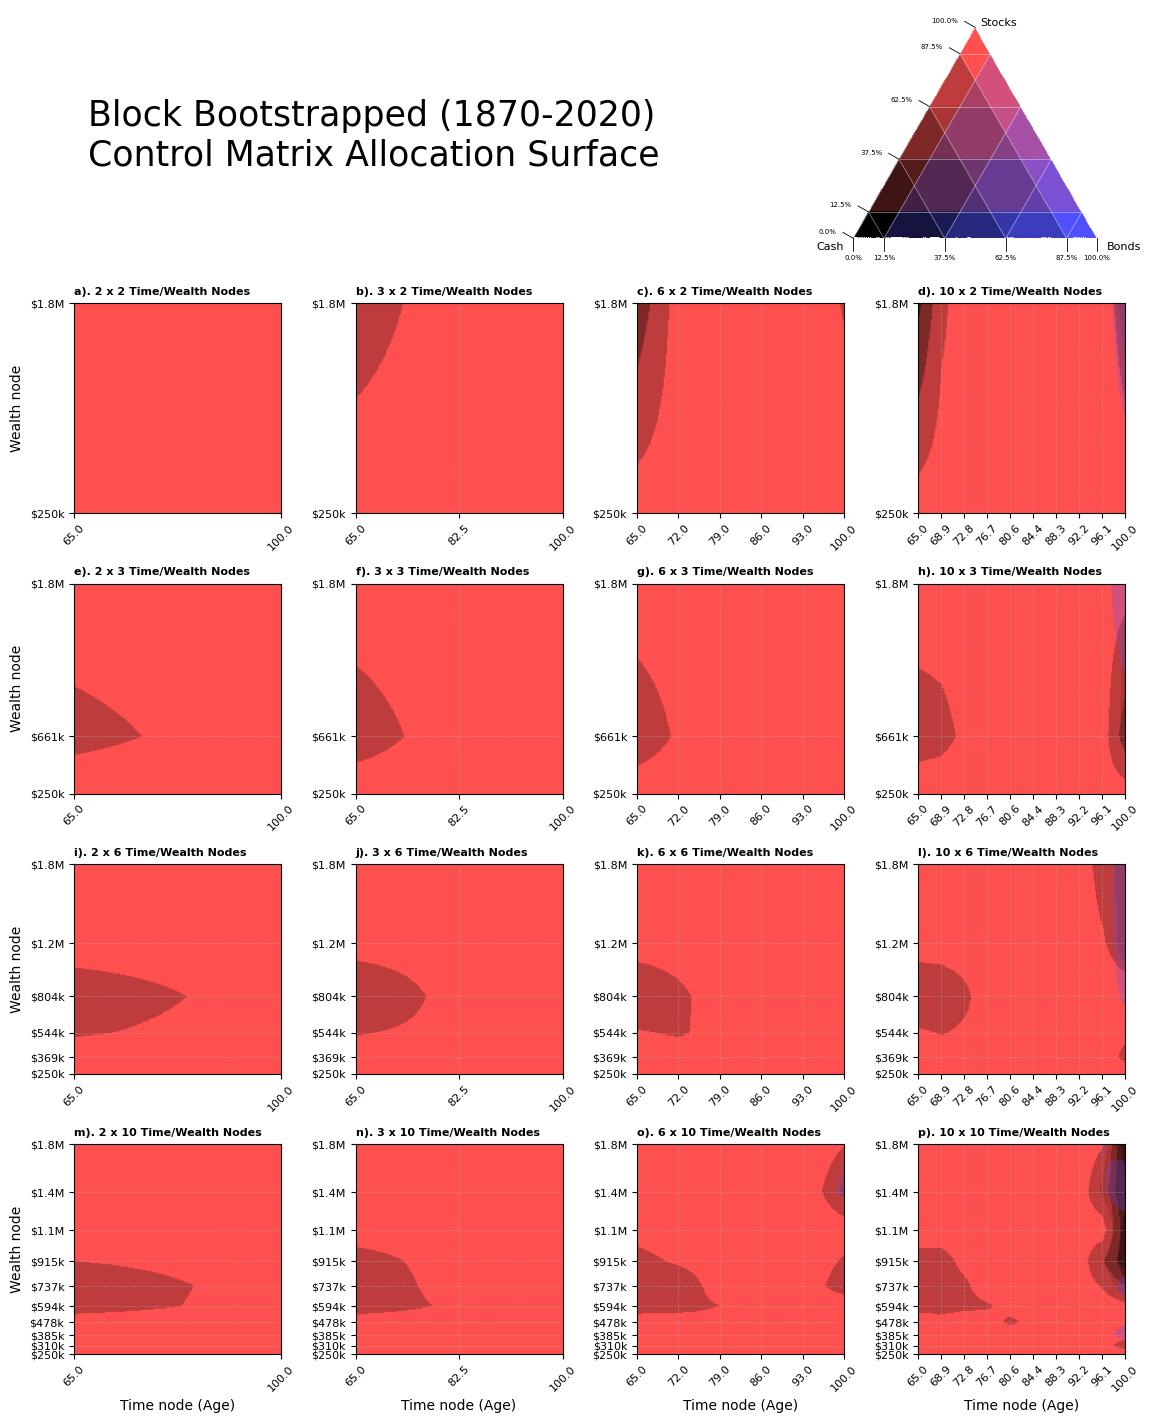

Saved: ./Plots\control_matrix_allocation_ternary_block_bootstrapped.png


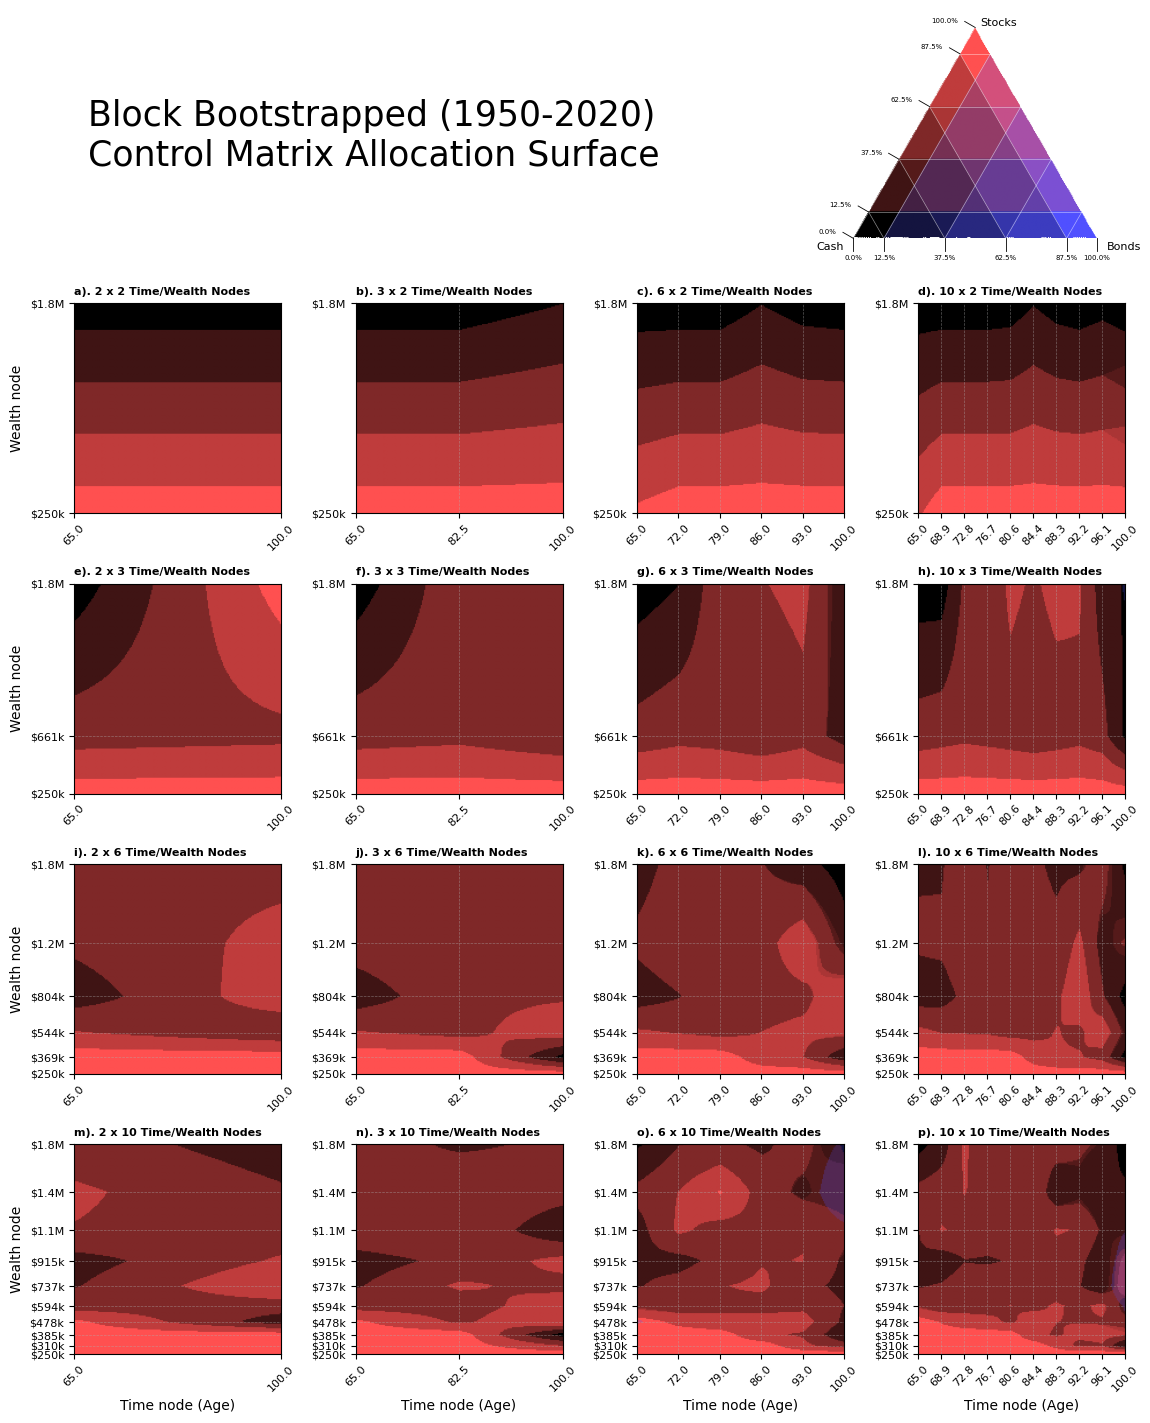

Saved: ./Plots\control_matrix_allocation_ternary_block_bootstrapped_1950.png


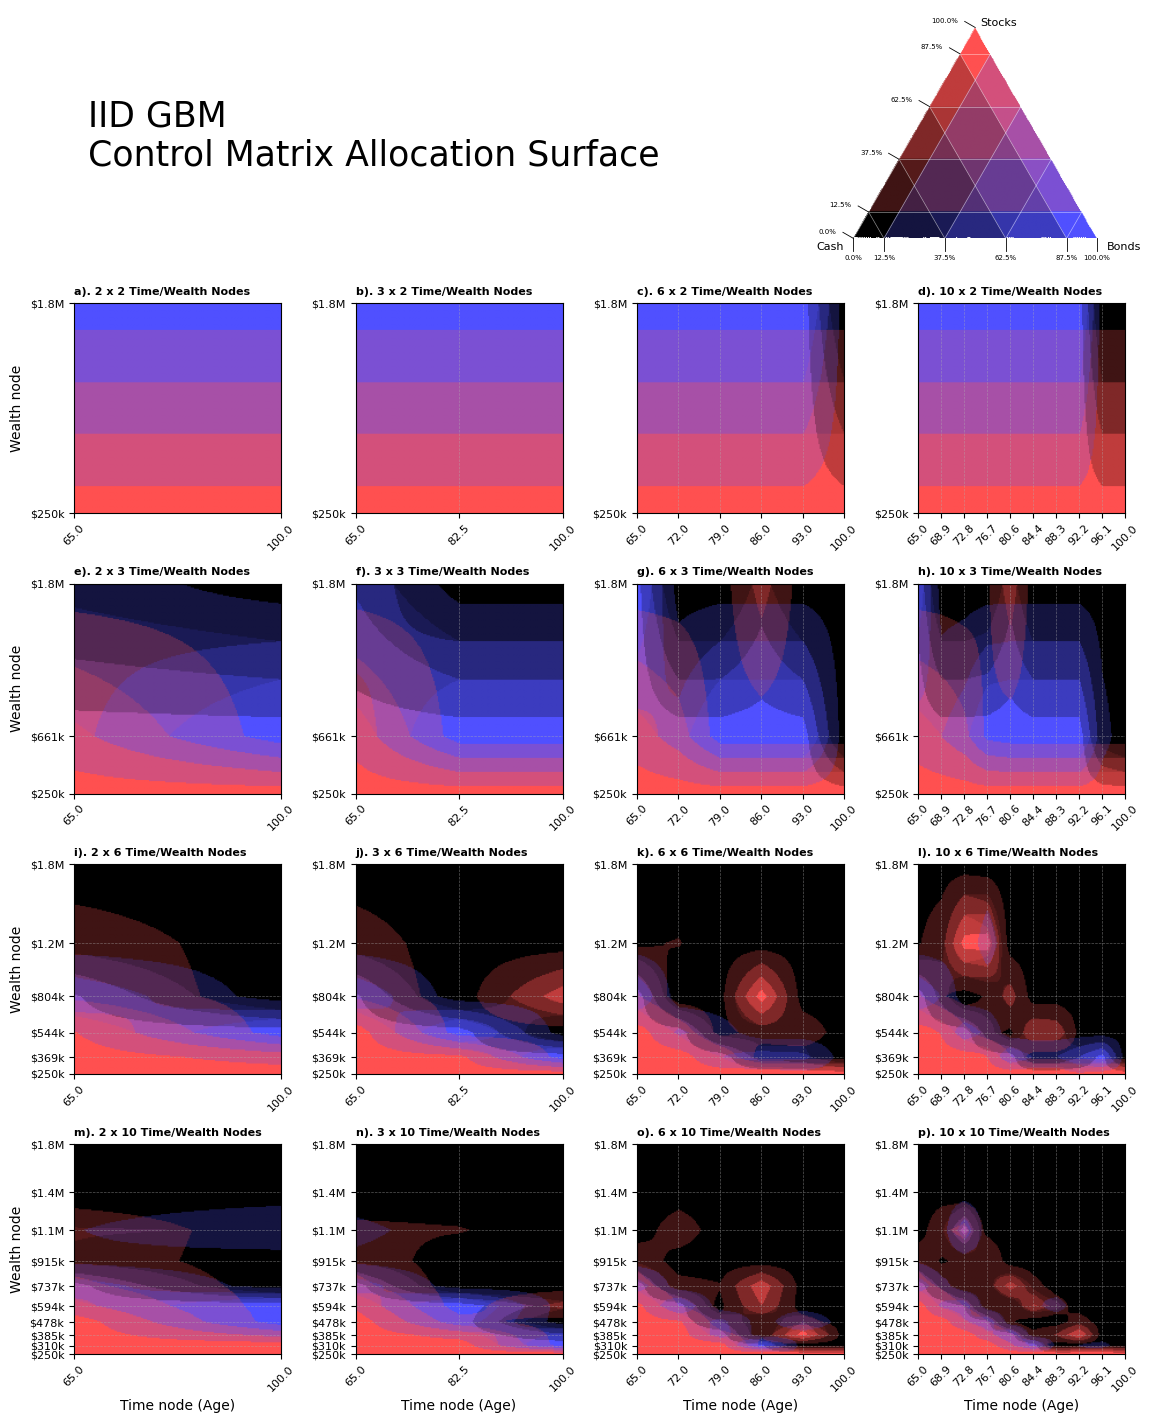

Saved: ./Plots\control_matrix_allocation_ternary_cholesky.png


In [ ]:
# Ternary RGB view: show Cash/Bonds/Stocks simultaneously on each time x wealth surface.
import numpy as np
import matplotlib.pyplot as plt

if "experiments" not in globals():
    raise RuntimeError("Run Cell 2 first (data loading).")
if "samplers" not in globals() or "time_counts" not in globals() or "wealth_counts" not in globals():
    raise RuntimeError("Run Cell 3 first (record preparation).")

# Vertex colors for ternary blending: Cash, Bonds, Stocks in CMY.
ASSET_VERTEX_COLORS = np.array([
    [0,0,0],          # Cash
    [80, 80, 255],    # Bonds
    [255, 80, 80 ],    # Stocks

], dtype=float) / 255.0

INTERP_TIME_POINTS_RGB = 180
INTERP_WEALTH_POINTS_RGB = 180
QUANTISATION_STEP = 0.25

# Quantise allocations to 10% buckets while keeping them summing to 1.
def _quantise_allocations(cash, bonds, stocks, step=0.1):
    cash_q = np.round(cash / step) * step
    bonds_q = np.round(bonds / step) * step
    stocks_q = np.round(stocks / step) * step
    total = np.clip(cash_q + bonds_q + stocks_q, 1e-12, None)
    return cash_q / total, bonds_q / total, stocks_q / total

def _interpolate_asset_surface(asset_surface, time_nodes, wealth_nodes, interp_time, interp_wealth):
    return _bilinear_interpolate_surface(
        surface=asset_surface,
        x_nodes=time_nodes,
        y_nodes=wealth_nodes,
        x_target=interp_time,
        y_target=interp_wealth,
    )

def _compose_rgb(cash, bonds, stocks):
    rgb = (
        cash[..., None] * ASSET_VERTEX_COLORS[0]
        + bonds[..., None] * ASSET_VERTEX_COLORS[1]
        + stocks[..., None] * ASSET_VERTEX_COLORS[2]
    )
    return np.clip(rgb, 0.0, 1.0)

def _ternary_legend_image(resolution=260):
    # Equilateral triangle vertices in Cartesian coordinates.
    v_cash = np.array([0.0, 0.0])
    v_bonds = np.array([1.0, 0.0])
    v_stocks = np.array([0.5, np.sqrt(3) / 2.0])

    xs = np.linspace(0.0, 1.0, resolution)
    ys = np.linspace(0.0, np.sqrt(3) / 2.0, resolution)
    xx, yy = np.meshgrid(xs, ys)

    # Barycentric coordinates for each pixel.
    den = (
        (v_bonds[1] - v_stocks[1]) * (v_cash[0] - v_stocks[0])
        + (v_stocks[0] - v_bonds[0]) * (v_cash[1] - v_stocks[1])
    )
    w_cash = (
        (v_bonds[1] - v_stocks[1]) * (xx - v_stocks[0])
        + (v_stocks[0] - v_bonds[0]) * (yy - v_stocks[1])
    ) / den
    w_bonds = (
        (v_stocks[1] - v_cash[1]) * (xx - v_stocks[0])
        + (v_cash[0] - v_stocks[0]) * (yy - v_stocks[1])
    ) / den
    w_stocks = 1.0 - w_cash - w_bonds

    inside = (w_cash >= 0.0) & (w_bonds >= 0.0) & (w_stocks >= 0.0)

    img = np.ones((resolution, resolution, 4), dtype=float)
    img[..., 3] = 0.0

    w_cash_q, w_bonds_q, w_stocks_q = _quantise_allocations(
        np.clip(w_cash, 0.0, 1.0),
        np.clip(w_bonds, 0.0, 1.0),
        np.clip(w_stocks, 0.0, 1.0),
        step=QUANTISATION_STEP
    )
    rgb_inside = _compose_rgb(w_cash_q, w_bonds_q, w_stocks_q)
    img[inside, :3] = rgb_inside[inside]
    img[inside, 3] = 1.0
    return img

def _draw_ternary_grid(ax, step, h):
    """Draw iso-lines at quantisation bucket boundaries on the ternary legend axes."""
    n_buckets = round(1 / step)
    # Tick values: 0, then centres of each transition boundary at (i+0.5)*step.
    tick_vals = np.concatenate([[0.0], (np.arange(n_buckets) + 0.5) * step])
    for t in tick_vals:
        # Cash iso-line: constant Cash = t, from Cash-Bonds edge to Cash-Stocks edge.
        ax.plot([1 - t, 0.5 * (1 - t)], [0.0, (1 - t) * h],
                color='white', lw=0.5, alpha=0.55, solid_capstyle='round')
        # Bonds iso-line: constant Bonds = t, from Cash-Bonds edge to Bonds-Stocks edge.
        ax.plot([t, 0.5 + 0.5 * t], [0.0, (1 - t) * h],
                color='white', lw=0.5, alpha=0.55, solid_capstyle='round')
        # Stocks iso-line: constant Stocks = t, from Cash-Stocks edge to Bonds-Stocks edge.
        ax.plot([0.5 * t, 1 - 0.5 * t], [t * h, t * h],
                color='white', lw=0.5, alpha=0.55, solid_capstyle='round')

def _draw_ternary_ticks(ax, step, h):
    """Draw tick marks and labels on the Bonds and Stocks axes (Cash-Bonds and Cash-Stocks edges).
    Labels run from 100% at the Bonds/Stocks vertex down to 0% at the Cash vertex.
    """
    n_buckets = round(1 / step)
    tick_vals = np.concatenate([[0.0], (np.arange(n_buckets) + 0.5) * step, [1]])

    tick_len = 0.05   # length of tick mark in data coords
    label_pad = 0.08  # distance from edge to label centre

    # Cash-Bonds edge: outward normal points downward (0, -1).
    bonds_normal = np.array([0.0, -1.0])
    # Cash-Stocks edge: outward normal points left and slightly up (-sqrt(3)/2, 0.5).
    stocks_normal = np.array([-np.sqrt(3) / 2.0, 0.5])

    for t in tick_vals:
        label = f"{t:.1%}"

        # --- Bonds tick on Cash-Bonds (bottom) edge ---
        # Position along edge: Bonds=t means x=t, y=0.
        bx, by = t, 0.0
        ax.plot(
            [bx, bx + tick_len * bonds_normal[0]],
            [by, by + tick_len * bonds_normal[1]],
            color='black', lw=0.6, clip_on=False,
        )
        ax.text(
            bx + label_pad * bonds_normal[0],
            by + label_pad * bonds_normal[1],
            label,
            fontsize=5, ha='center', va='center', clip_on=False,
        )

        # --- Stocks tick on Cash-Stocks (left) edge ---
        # Position along edge: Stocks=t means x=0.5*t, y=t*h.
        sx, sy = 0.5 * t, t * h
        ax.plot(
            [sx, sx + tick_len * stocks_normal[0]],
            [sy, sy + tick_len * stocks_normal[1]],
            color='black', lw=0.6, clip_on=False,
        )
        ax.text(
            sx + label_pad * stocks_normal[0],
            sy + label_pad * stocks_normal[1],
            label,
            fontsize=5, ha='right', va='top', clip_on=False,
        )

# Build best full-policy map by (sampler, time_count, wealth_count).
best_policy_map = {}
for payload in experiments:
    cfg = payload["config"]
    res = payload["result"]

    t_count = int(cfg.TIME_NODE_COUNT)
    w_count = int(cfg.WEALTH_NODE_COUNT)
    if t_count <= 1 or w_count <= 1:
        continue

    policy = np.asarray(res.best_policy, dtype=float)
    if policy.ndim != 3 or policy.shape[2] < 2:
        continue

    key = (cfg.RETURN_SAMPLER, t_count, w_count)
    utility = float(res.best_utility)
    prev = best_policy_map.get(key)
    if prev is None or utility > prev["best_utility"]:
        best_policy_map[key] = {
            "best_utility": utility,
            "policy": policy,
            "time_nodes": np.asarray(res.time_nodes, dtype=float),
            "wealth_nodes": np.asarray(res.wealth_nodes, dtype=float),
        }
from plot_utils import RETURN_SAMPLER_DISPLAY_NAMES, _get_plot_letter

# Reserve a thin top band for a horizontal title + legend row.
_TOP_BAND_Y = 0.95
_TOP_LAYOUT_CUTOFF = 0.85
_LEGEND_RIGHT = 0.95
_LEGEND_WIDTH = 0.23
_LEGEND_HEIGHT = 0.23
_TITLE_LEFT = 0.08

for sampler in samplers:
    n_rows = len(wealth_counts)
    n_cols = len(time_counts)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(2.9 * n_cols, 3.4 * n_rows),
        squeeze=False,
    )

    for row_idx, wealth_count in enumerate(wealth_counts):
        for col_idx, time_count in enumerate(time_counts):
            ax = axes[row_idx, col_idx]
            key = (sampler, time_count, wealth_count)
            rec = best_policy_map.get(key)

            if rec is None:
                ax.set_axis_off()
                ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
                continue

            time_nodes = rec["time_nodes"]
            wealth_nodes = rec["wealth_nodes"]
            policy = rec["policy"]

            interp_time = np.linspace(time_nodes.min(), time_nodes.max(), INTERP_TIME_POINTS_RGB)
            interp_wealth = np.linspace(wealth_nodes.min(), wealth_nodes.max(), INTERP_WEALTH_POINTS_RGB)

            bonds_interp = _interpolate_asset_surface(
                policy[:, :, 0],
                time_nodes,
                wealth_nodes,
                interp_time,
                interp_wealth,
            )
            stocks_interp = _interpolate_asset_surface(
                policy[:, :, 1],
                time_nodes,
                wealth_nodes,
                interp_time,
                interp_wealth,
            )
            cash_interp = 1.0 - bonds_interp - stocks_interp

            # Keep allocations compositional after interpolation.
            cash_interp = np.clip(cash_interp, 0.0, 1.0)
            bonds_interp = np.clip(bonds_interp, 0.0, 1.0)
            stocks_interp = np.clip(stocks_interp, 0.0, 1.0)
            total = np.clip(cash_interp + bonds_interp + stocks_interp, 1e-12, None)
            cash_interp /= total
            bonds_interp /= total
            stocks_interp /= total

            # Quantise to buckets.
            cash_interp, bonds_interp, stocks_interp = _quantise_allocations(
                cash_interp, bonds_interp, stocks_interp, step=QUANTISATION_STEP
            )

            rgb_img = _compose_rgb(cash_interp, bonds_interp, stocks_interp)

            ax.imshow(
                rgb_img.transpose(1, 0, 2),
                origin="lower",
                aspect="auto",
                extent=[interp_time.min(), interp_time.max(), interp_wealth.min(), interp_wealth.max()],
            )
            plot_letter = _get_plot_letter(row_idx, col_idx, n_cols)
            
            ax.set_title(f"{plot_letter} {time_count} x {wealth_count} Time/Wealth Nodes", fontsize=8, weight='bold', loc='left')
            ax.set_xticks(time_nodes)
            ax.set_xticklabels([f"{(t+65):.1f}" for t in time_nodes], fontsize=8, rotation=45)
            ax.set_yticks(wealth_nodes)
            ax.set_yticklabels([_format_money_tick(w) for w in wealth_nodes], fontsize=8)
            ax.set_xlim(time_nodes.min(), time_nodes.max())
            ax.set_ylim(wealth_nodes.min(), wealth_nodes.max())
            ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

            if row_idx == n_rows - 1:
                ax.set_xlabel("Time node (Age)")
            if col_idx == 0:
                ax.set_ylabel("Wealth node")

    # Keep subplot area below the top title/legend band.
    fig.tight_layout(rect=[0, 0, 1, _TOP_LAYOUT_CUTOFF])

    # Add ternary legend in the top margin, aligned to the right.
    _legend_h = np.sqrt(3) / 2.0
    legend_left = _LEGEND_RIGHT - _LEGEND_WIDTH
    legend_bottom = _TOP_BAND_Y - (_LEGEND_HEIGHT / 2.0)
    legend_ax = fig.add_axes([legend_left, legend_bottom, _LEGEND_WIDTH, _LEGEND_HEIGHT])
    legend_img = _ternary_legend_image()
    legend_ax.imshow(
        legend_img,
        origin="lower",
        extent=[0.0, 1.0, 0.0, _legend_h],
        interpolation=None,
    )
    _draw_ternary_grid(legend_ax, QUANTISATION_STEP, _legend_h)
    _draw_ternary_ticks(legend_ax, QUANTISATION_STEP, _legend_h)
    legend_ax.set_axis_off()
    legend_ax.text(0.0, 0.08, "Cash", fontsize=8, ha="center", va="top",
                   transform=legend_ax.transAxes)
    legend_ax.text(1.1, 0.08, "Bonds", fontsize=8, ha="center", va="top",
                   transform=legend_ax.transAxes)
    legend_ax.text(0.63, 0.93, "Stocks", fontsize=8, ha="center", va="bottom",
                   transform=legend_ax.transAxes)

    # Place title inline, to the left of the top-margin legend.
    sampler_name = RETURN_SAMPLER_DISPLAY_NAMES.get(sampler, sampler).replace("\n", " ")
    
    fig.text(
        _TITLE_LEFT,
        _TOP_BAND_Y,
        f"{sampler_name} \nControl Matrix Allocation Surface",
        fontsize=25,
        ha="left",
        va="center",
    )

    out_file = os.path.join(PLOTS_DIR, f"control_matrix_allocation_ternary_{sampler}.png")
    fig.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_file}")


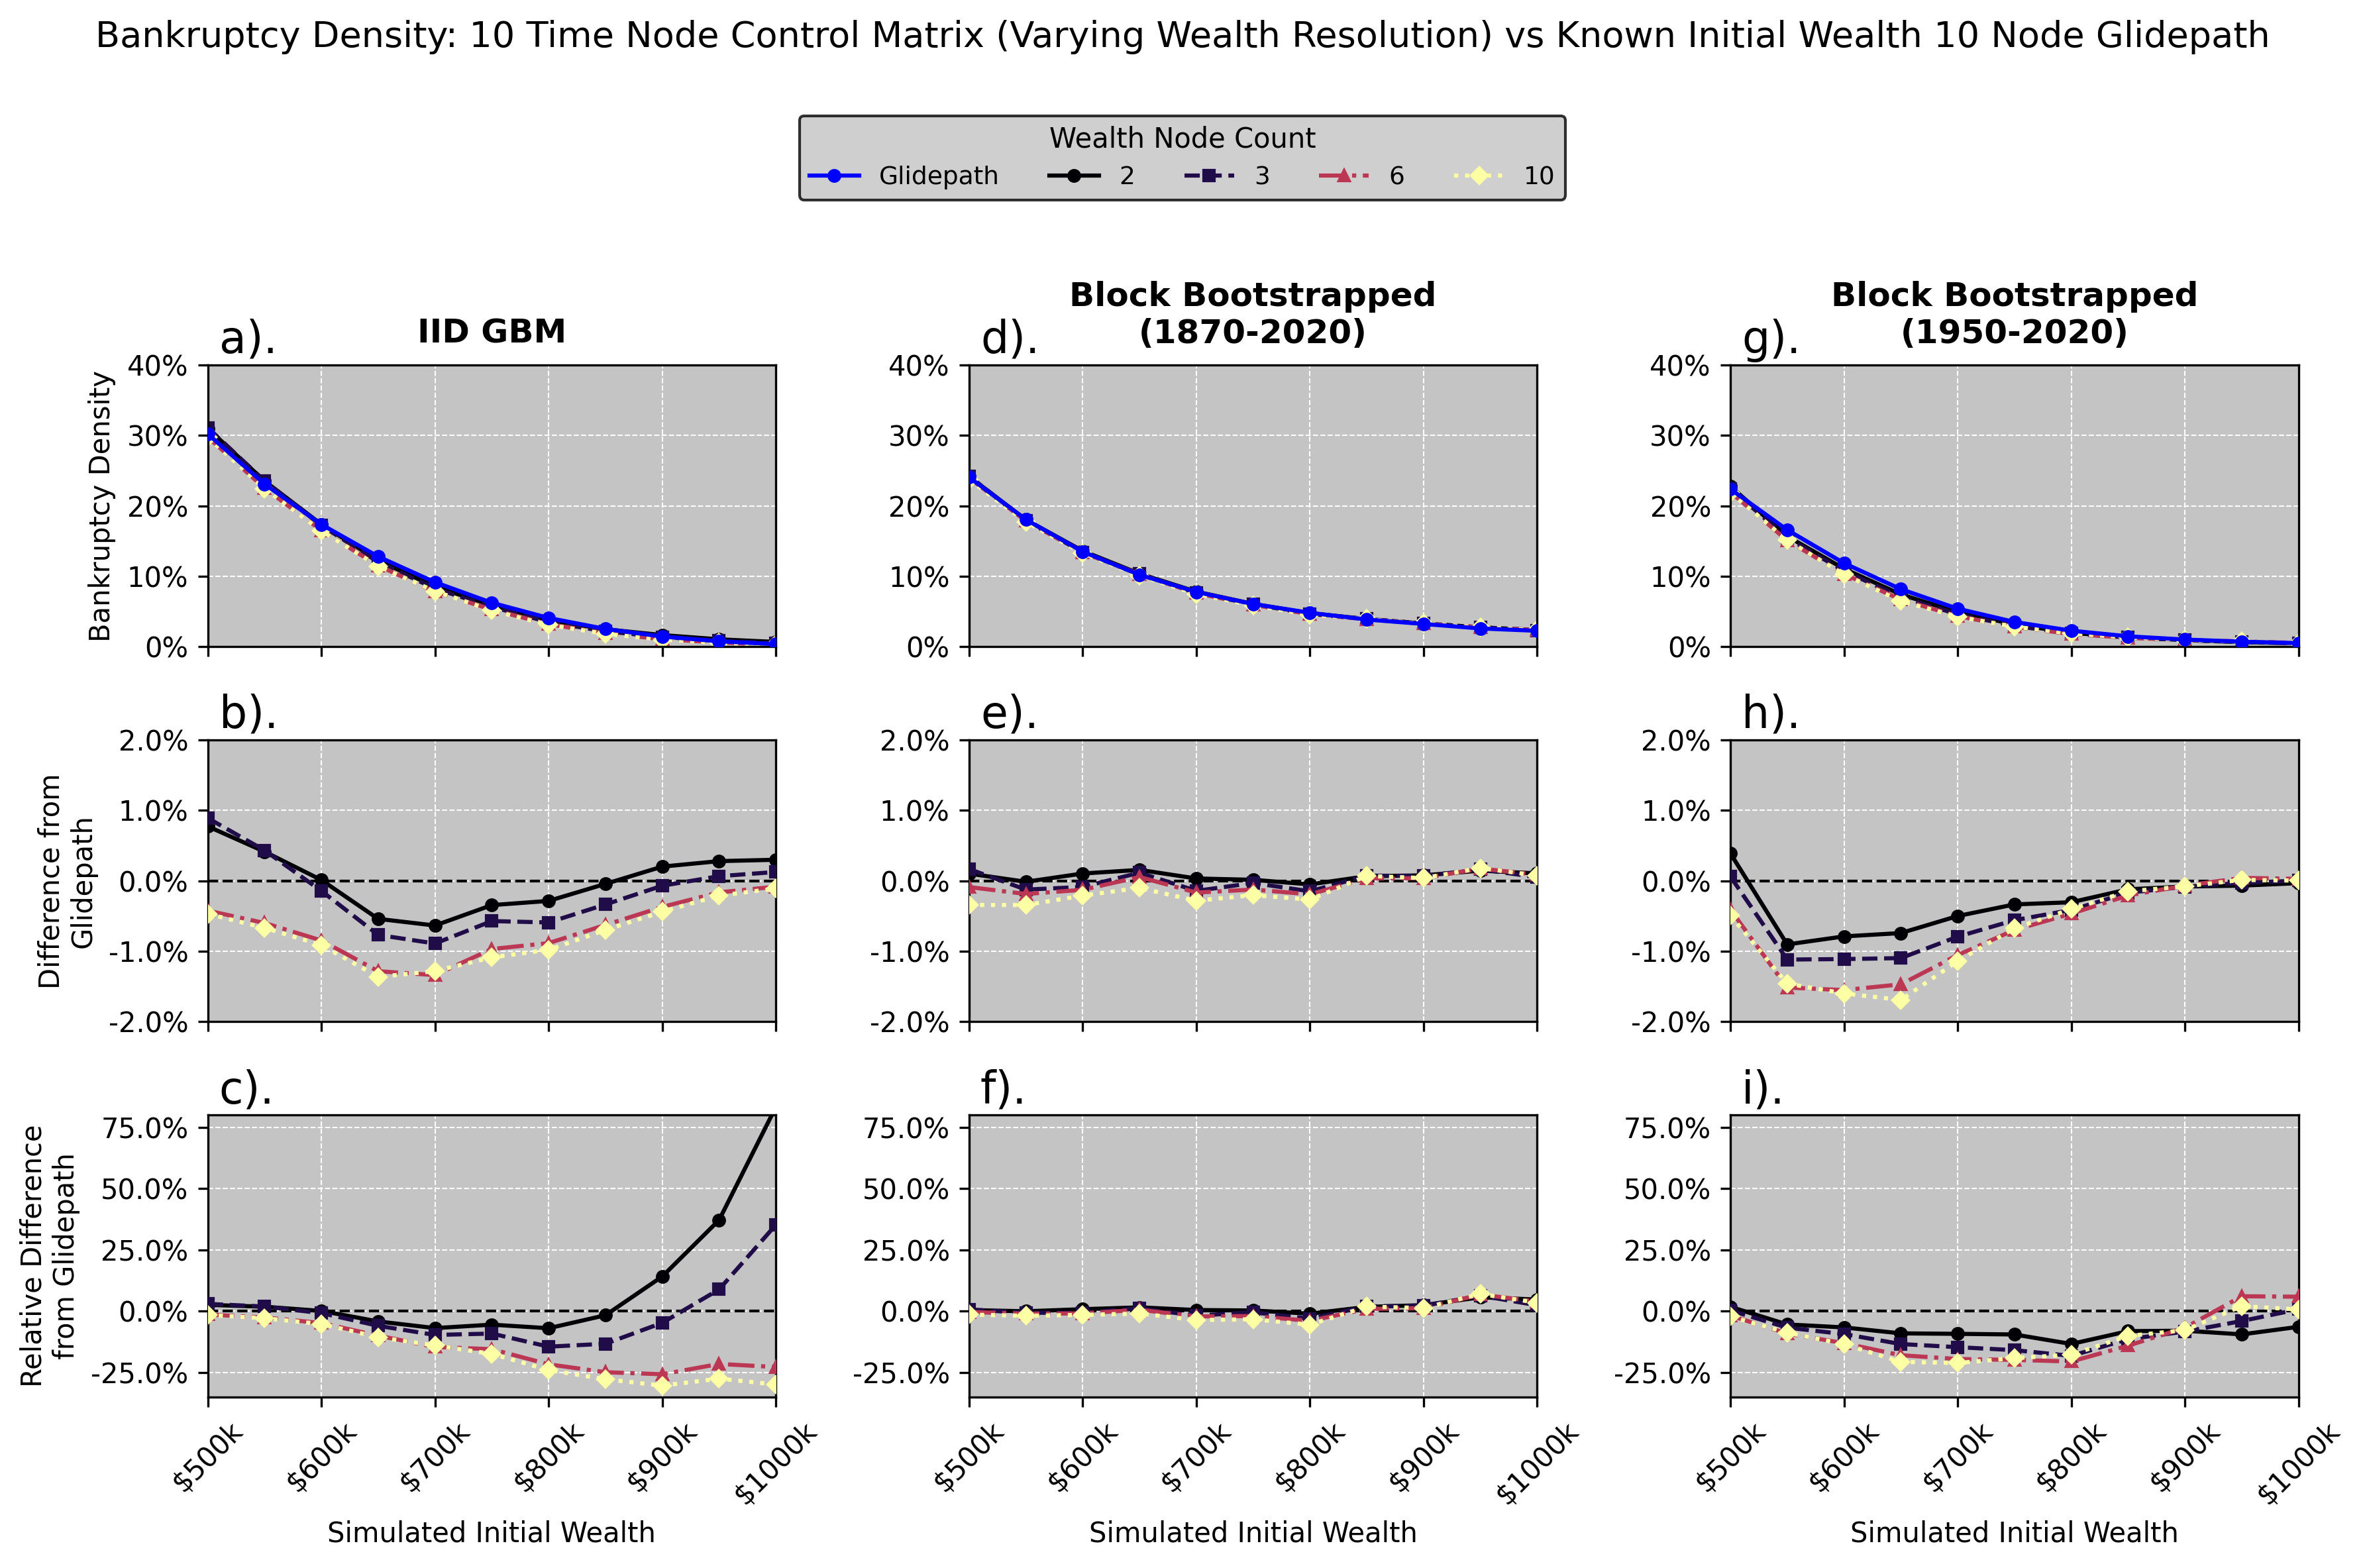

In [ ]:
# Compare bankruptcy density bucket-by-bucket using saved parquet outputs only:
# Control Matrix (distributed wealth) vs Time-Based (known initial wealth baseline).
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

from plot_utils import plot_metric_vs_known_wealth_fixed_baseline, RETURN_SAMPLER_DISPLAY_NAMES

EXPERIMENTS_PARQUET = "./Results/optimisation_experiments.parquet"
OUTCOMES_PARQUET = "./Results/optimisation_outcomes.parquet"

experiment_df = pl.read_parquet(EXPERIMENTS_PARQUET)
outcomes_df = pl.read_parquet(OUTCOMES_PARQUET)

joined = outcomes_df.join(
    experiment_df.select([
        "experiment_file",
        "initial_wealth",
        "n_time_nodes",
        "n_wealth_nodes",
        "sampler",
    ]),
    on="experiment_file",
    how="inner",
)

# Fixed baseline: Time-based known-wealth runs at T=10, W=1.
fixed_baseline_data = (
    joined
    .filter(
        (pl.col("n_time_nodes") == 10)
        & (pl.col("n_wealth_nodes") == 1)
        & (pl.col("initial_wealth").is_not_null())
    )
    .group_by(["sampler", "simulated_initial_wealth"])
    .agg(pl.col("bankruptcy_density").mean().alias("bankruptcy_density"))
)

# Outcome node data: distributed-wealth control matrix runs at T=10 with varying W.
outcome_node_data = (
    joined
    .filter(
        (pl.col("n_time_nodes") == 10)
        & (pl.col("initial_wealth").is_null())
    )
    .group_by(["sampler", "n_wealth_nodes", "simulated_initial_wealth"])
    .agg(pl.col("bankruptcy_density").mean().alias("bankruptcy_density"))
    .with_columns(pl.lit(10).alias("n_time_nodes"))
)

# Keep only samplers that exist in both datasets.
baseline_samplers = set(fixed_baseline_data["sampler"].unique().to_list())
outcome_samplers = set(outcome_node_data["sampler"].unique().to_list())
samplers_to_plot = sorted(baseline_samplers.intersection(outcome_samplers))

if not samplers_to_plot:
    raise RuntimeError(
        "No overlapping samplers found between fixed baseline and outcome node data."
    )

# Choose available control-matrix wealth node counts (excluding W=1 baseline style run).
nodes_to_plot = sorted(
    n for n in outcome_node_data["n_wealth_nodes"].unique().to_list()
    if int(n) > 1
)

if not nodes_to_plot:
    raise RuntimeError("No distributed-wealth control-matrix node counts available to plot.")

fig, axes = plot_metric_vs_known_wealth_fixed_baseline(
    outcome_node_data=outcome_node_data,
    fixed_baseline_data=fixed_baseline_data,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    node_dimension="wealth",
    metric="bankruptcy_density",
    metric_label="Bankruptcy Density",
    diff_label="Difference from\nGlidepath",
    rel_diff_label="Relative Difference\nfrom Glidepath",
    rel_diff_ylim=(-.35,.8),
    diff_ylim=(-0.02, 0.02),
    top_ylim=(0.0, 0.4),
    top_as_percent=True,
    diff_as_percent=True,
    rel_diff_as_percent=True,
    sampler_display_names=RETURN_SAMPLER_DISPLAY_NAMES,
    baseline_label="Glidepath",
    legend_title="Wealth Node Count",
)

fig.suptitle(
    "Bankruptcy Density: 10 Time Node Control Matrix (Varying Wealth Resolution) vs Known Initial Wealth 10 Node Glidepath",
    fontsize=13,
    y=1.12,
)

fig.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bankruptcy_density_control_matrix_vs_glidepath.png"), dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.show()


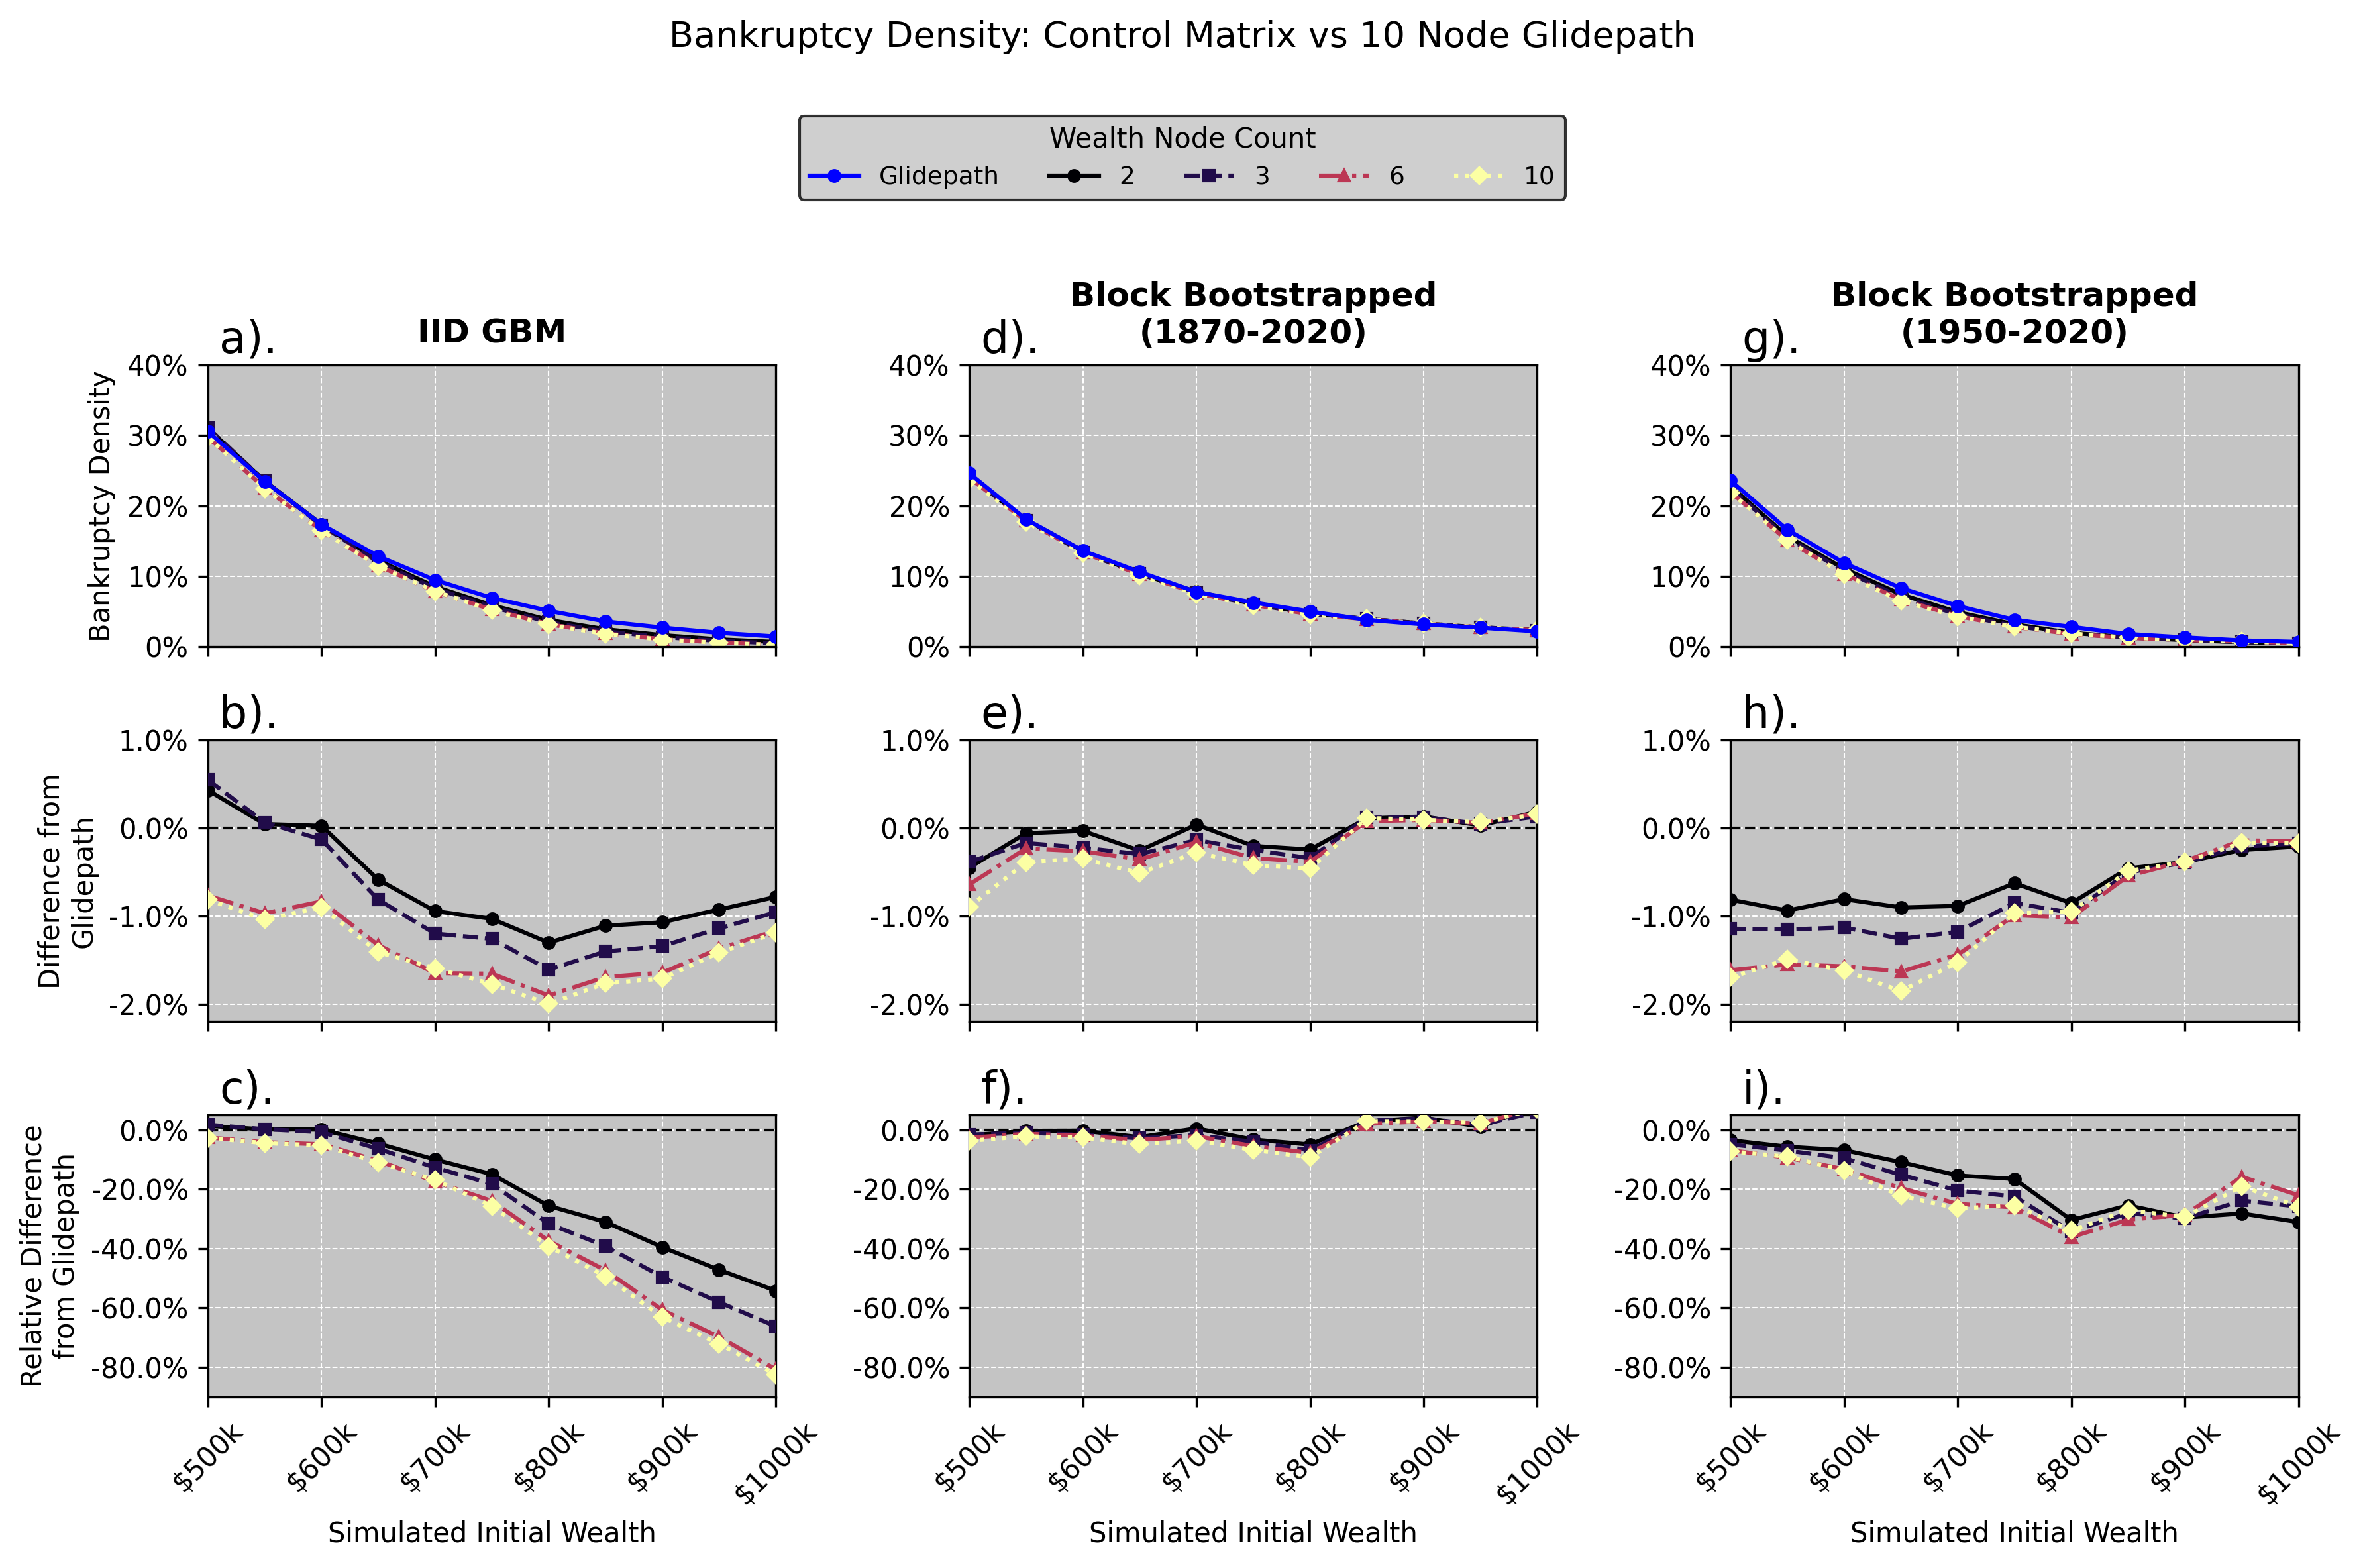

In [ ]:
# Compare bankruptcy density bucket-by-bucket using saved parquet outputs only:
# Control Matrix (distributed wealth) vs Time-Based (distributed initial wealth baseline).
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

from plot_utils import plot_metric_vs_known_wealth_fixed_baseline, RETURN_SAMPLER_DISPLAY_NAMES

EXPERIMENTS_PARQUET = "./Results/optimisation_experiments.parquet"
OUTCOMES_PARQUET = "./Results/optimisation_outcomes.parquet"

experiment_df = pl.read_parquet(EXPERIMENTS_PARQUET)
outcomes_df = pl.read_parquet(OUTCOMES_PARQUET)

joined = outcomes_df.join(
    experiment_df.select([
        "experiment_file",
        "initial_wealth",
        "n_time_nodes",
        "n_wealth_nodes",
        "sampler",
    ]),
    on="experiment_file",
    how="inner",
)

# Fixed baseline: Time-based known-wealth runs at T=10, W=1.
fixed_baseline_data = (
    joined
    .filter(
        (pl.col("n_time_nodes") == 10)
        & (pl.col("n_wealth_nodes") == 1)
        & (pl.col("initial_wealth").is_null())
    )
    .group_by(["sampler", "simulated_initial_wealth"])
    .agg(pl.col("bankruptcy_density").mean().alias("bankruptcy_density"))
)

# Outcome node data: distributed-wealth control matrix runs at T=10 with varying W.
outcome_node_data = (
    joined
    .filter(
        (pl.col("n_time_nodes") == 10)
        & (pl.col("initial_wealth").is_null())
    )
    .group_by(["sampler", "n_wealth_nodes", "simulated_initial_wealth"])
    .agg(pl.col("bankruptcy_density").mean().alias("bankruptcy_density"))
    .with_columns(pl.lit(10).alias("n_time_nodes"))
)

# Keep only samplers that exist in both datasets.
baseline_samplers = set(fixed_baseline_data["sampler"].unique().to_list())
outcome_samplers = set(outcome_node_data["sampler"].unique().to_list())
samplers_to_plot = sorted(baseline_samplers.intersection(outcome_samplers))

if not samplers_to_plot:
    raise RuntimeError(
        "No overlapping samplers found between fixed baseline and outcome node data."
    )

# Choose available control-matrix wealth node counts (excluding W=1 baseline style run).
nodes_to_plot = sorted(
    n for n in outcome_node_data["n_wealth_nodes"].unique().to_list()
    if int(n) > 1
)

if not nodes_to_plot:
    raise RuntimeError("No distributed-wealth control-matrix node counts available to plot.")

fig, axes = plot_metric_vs_known_wealth_fixed_baseline(
    outcome_node_data=outcome_node_data,
    fixed_baseline_data=fixed_baseline_data,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    node_dimension="wealth",
    metric="bankruptcy_density",
    metric_label="Bankruptcy Density",
    diff_label="Difference from\nGlidepath",
    rel_diff_label="Relative Difference\nfrom Glidepath",
    rel_diff_ylim=(-.9,.05),
    diff_ylim=(-0.022, 0.01),
    top_ylim=(0.0, 0.4),
    top_as_percent=True,
    diff_as_percent=True,
    rel_diff_as_percent=True,
    sampler_display_names=RETURN_SAMPLER_DISPLAY_NAMES,
    baseline_label="Glidepath",
    legend_title="Wealth Node Count"
)

fig.suptitle(
    "Bankruptcy Density: 10 Time Node Control Matrix (Varying Wealth Resolution) vs 10 Node Glidepath",
    fontsize=13,
    y=1.12,
)

fig.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bankruptcy_density_control_matrix_vs_dist_glidepath.png"), dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.show()


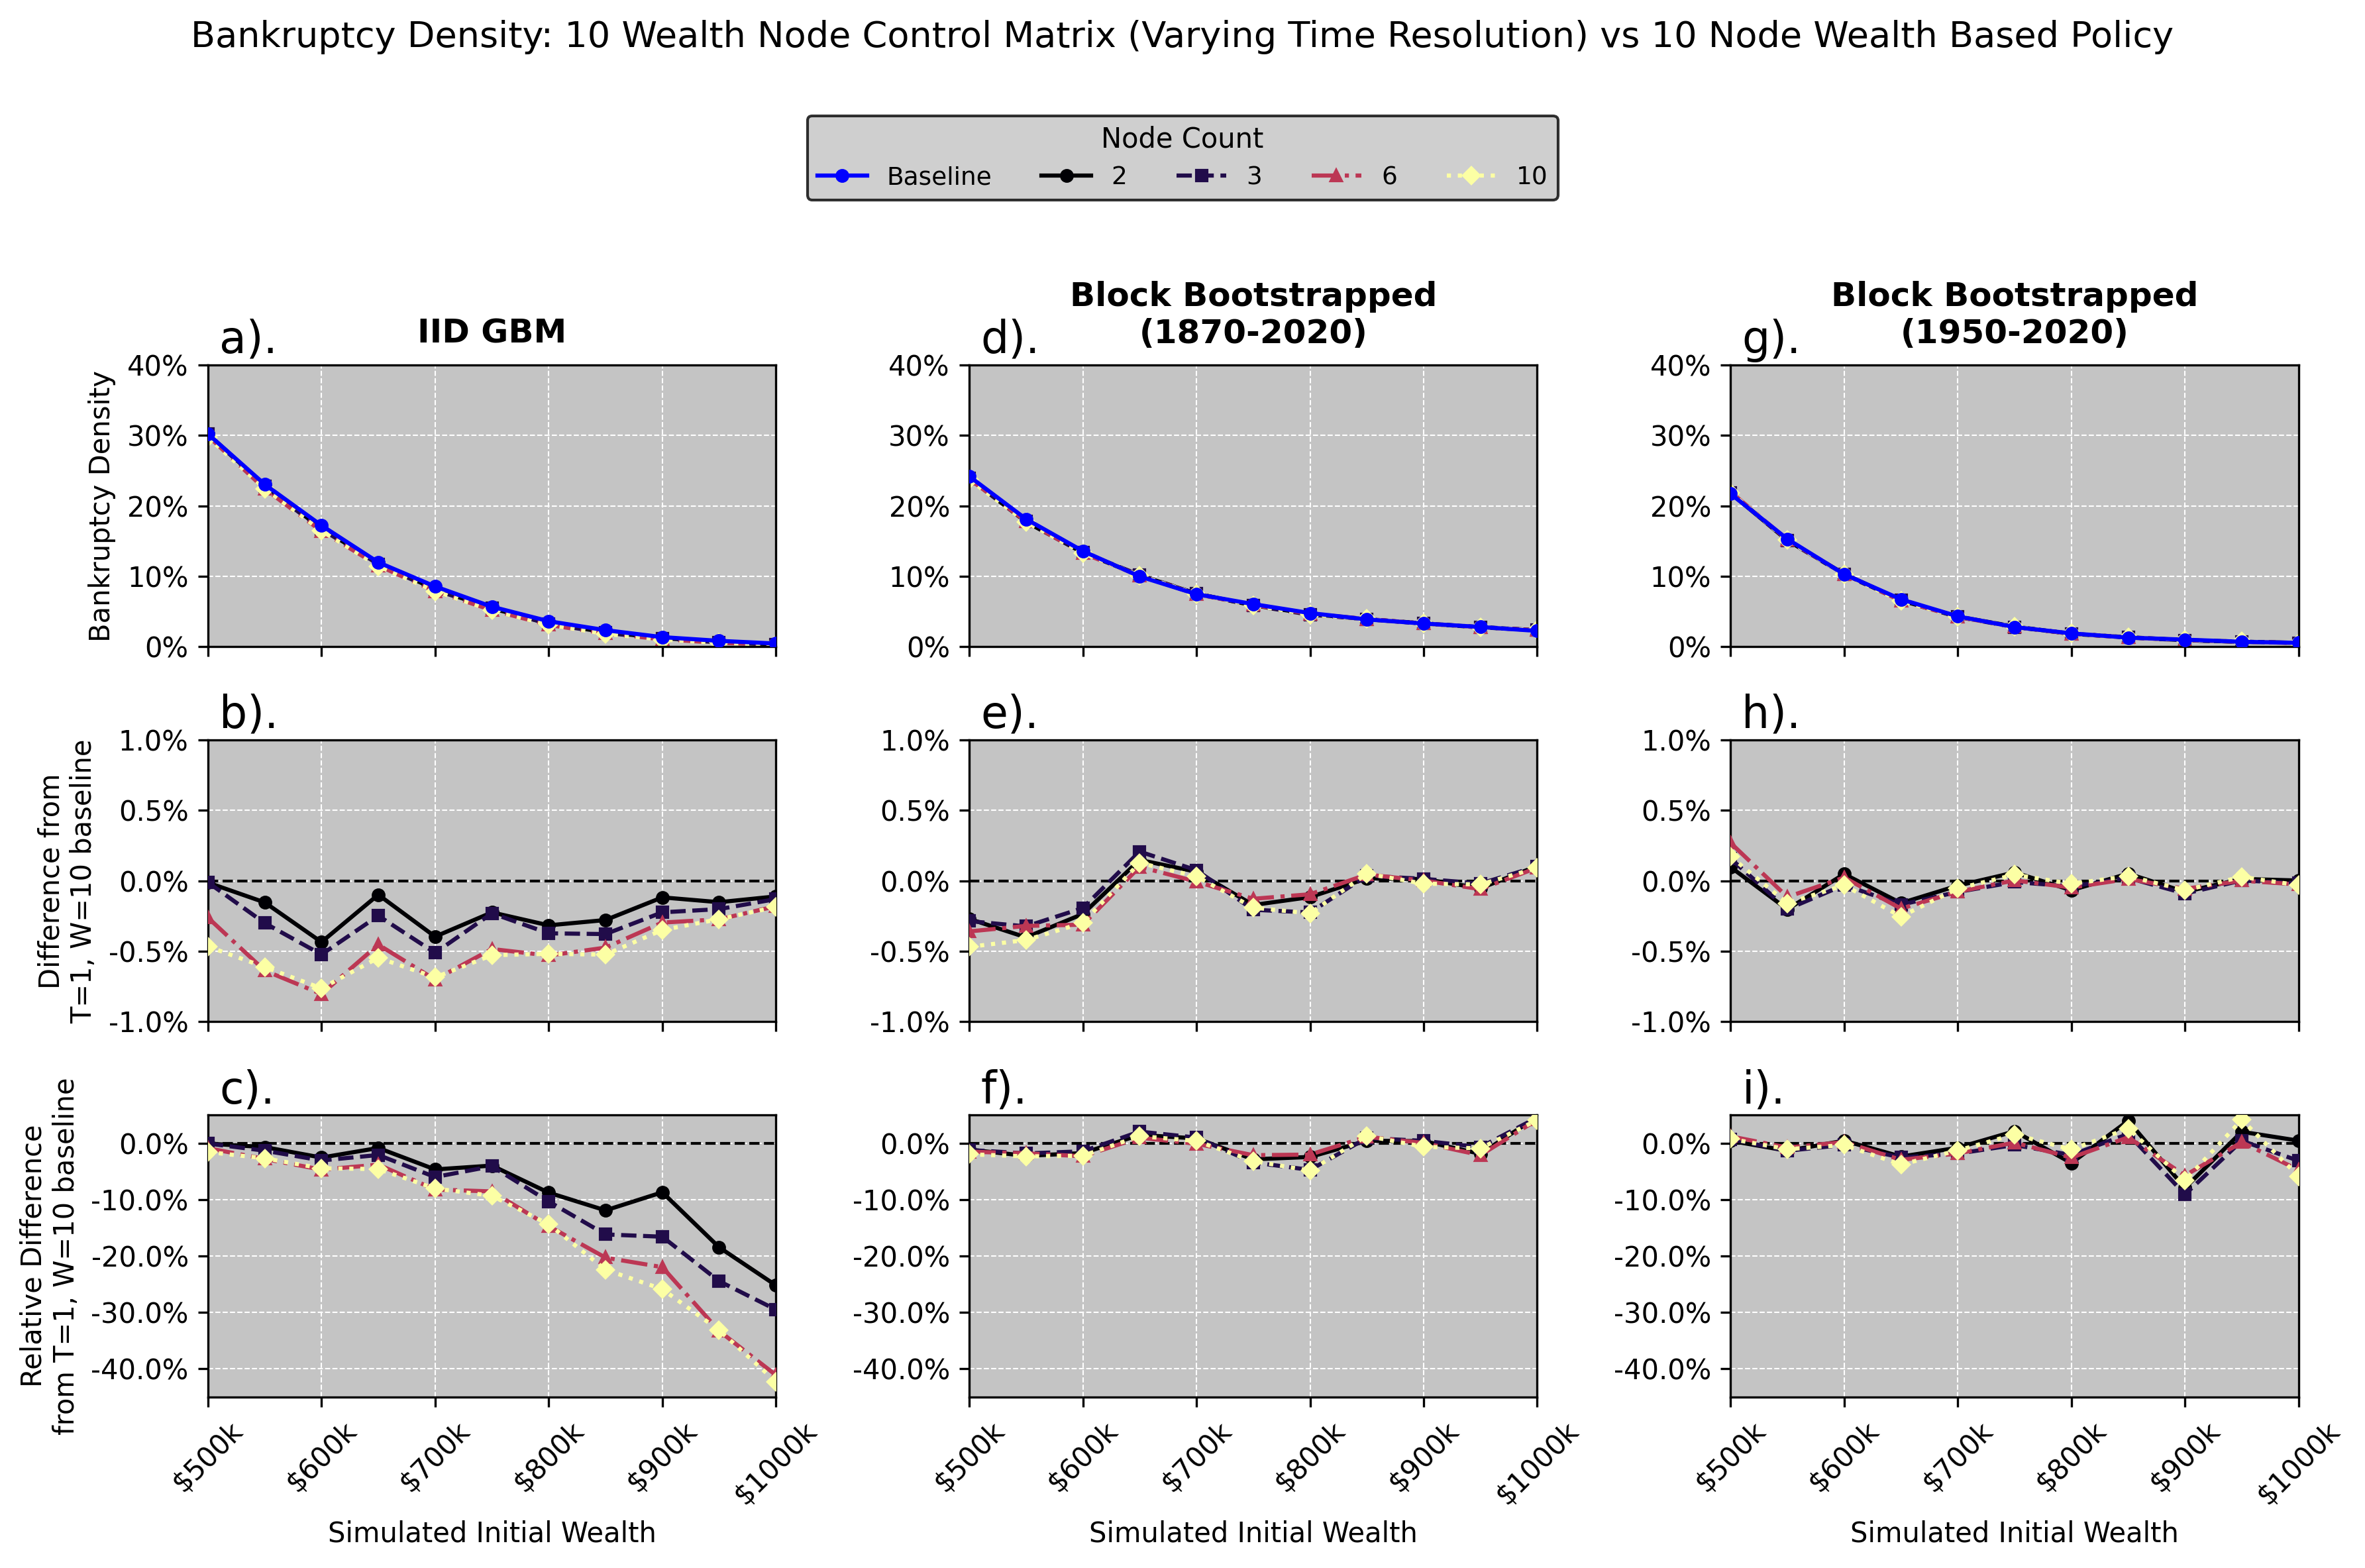

In [ ]:
# Compare bankruptcy density bucket-by-bucket using saved parquet outputs only:
# Control Matrix (distributed wealth) vs baseline at T=1, W=10 (distributed initial wealth).
# Here we vary time-node resolution (T) while keeping wealth-node count fixed at W=10.
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

from plot_utils import plot_metric_vs_known_wealth_fixed_baseline, RETURN_SAMPLER_DISPLAY_NAMES

EXPERIMENTS_PARQUET = "./Results/optimisation_experiments.parquet"
OUTCOMES_PARQUET = "./Results/optimisation_outcomes.parquet"

experiment_df = pl.read_parquet(EXPERIMENTS_PARQUET)
outcomes_df = pl.read_parquet(OUTCOMES_PARQUET)

joined = outcomes_df.join(
    experiment_df.select([
        "experiment_file",
        "initial_wealth",
        "n_time_nodes",
        "n_wealth_nodes",
        "sampler",
    ]),
    on="experiment_file",
    how="inner",
)

# Fixed baseline: distributed-wealth runs at T=1, W=10.
fixed_baseline_data = (
    joined
    .filter(
        (pl.col("n_time_nodes") == 1)
        & (pl.col("n_wealth_nodes") == 10)
        & (pl.col("initial_wealth").is_null())
    )
    .group_by(["sampler", "simulated_initial_wealth"])
    .agg(pl.col("bankruptcy_density").mean().alias("bankruptcy_density"))
)

# Outcome node data: distributed-wealth control matrix runs at W=10 with varying T.
outcome_node_data = (
    joined
    .filter(
        (pl.col("n_wealth_nodes") == 10)
        & (pl.col("initial_wealth").is_null())
    )
    .group_by(["sampler", "n_time_nodes", "simulated_initial_wealth"])
    .agg(pl.col("bankruptcy_density").mean().alias("bankruptcy_density"))
    .with_columns(pl.lit(10).alias("n_wealth_nodes"))
)

# Keep only samplers that exist in both datasets.
baseline_samplers = set(fixed_baseline_data["sampler"].unique().to_list())
outcome_samplers = set(outcome_node_data["sampler"].unique().to_list())
samplers_to_plot = sorted(baseline_samplers.intersection(outcome_samplers))

if not samplers_to_plot:
    raise RuntimeError(
        "No overlapping samplers found between T=1,W=10 baseline and outcome node data."
    )

# Choose available control-matrix time node counts (excluding the T=1 baseline).
nodes_to_plot = sorted(
    n for n in outcome_node_data["n_time_nodes"].unique().to_list()
    if int(n) > 1
)

if not nodes_to_plot:
    raise RuntimeError("No distributed-wealth control-matrix time node counts available to plot.")

fig, axes = plot_metric_vs_known_wealth_fixed_baseline(
    outcome_node_data=outcome_node_data,
    fixed_baseline_data=fixed_baseline_data,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    node_dimension="time",
    metric="bankruptcy_density",
    metric_label="Bankruptcy Density",
    diff_label="Difference from\nT=1, W=10 baseline",
    rel_diff_label="Relative Difference\nfrom T=1, W=10 baseline",
    rel_diff_ylim=(-.45,0.05),
    diff_ylim=(-0.01, 0.01),
    top_ylim=(0.0, 0.4),
    top_as_percent=True,
    diff_as_percent=True,
    rel_diff_as_percent=True,
    sampler_display_names=RETURN_SAMPLER_DISPLAY_NAMES,
)

fig.suptitle(
    "Bankruptcy Density: 10 Wealth Node Control Matrix (Varying Time Resolution) vs 10 Node Wealth Based Policy",
    fontsize=13,
    y=1.12,
)

fig.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bankruptcy_density_control_matrix_time_resolution_vs_t1_w10_baseline.png"), dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.show()


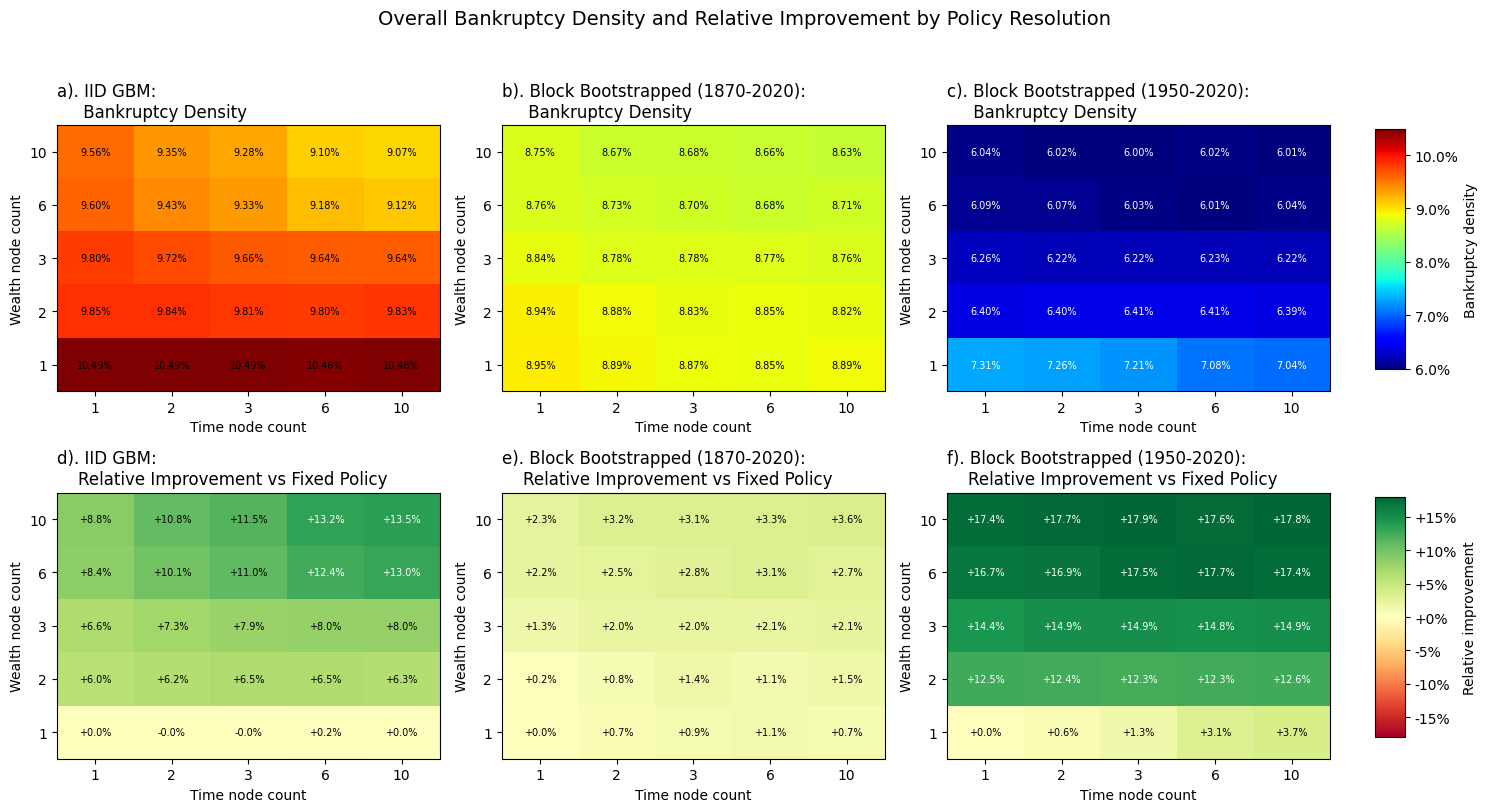

sampler,n_time_nodes,n_wealth_nodes,mean_bankruptcy_density
str,i64,i64,f64
"""block_bootstrapped""",1,1,0.089546
"""block_bootstrapped""",2,1,0.0889275
"""block_bootstrapped""",3,1,0.088699
"""block_bootstrapped""",6,1,0.088539
"""block_bootstrapped""",10,1,0.088902
…,…,…,…
"""cholesky""",1,10,0.09561
"""cholesky""",2,10,0.09353
"""cholesky""",3,10,0.092771


In [ ]:
# Heatmap: overall (simulation-weighted) bankruptcy density by node counts, split by sampler.
# Adds a second row with relative improvement vs fixed-policy baseline.
nodes_to_plot = [1, 2, 3, 6, 10]
FIXED_POLICY_LABEL = "1.1"

overall_bankruptcy = (
    joined
    .with_columns(
        (pl.col("bankruptcy_density") * pl.col("n_simulations")).alias("weighted_bankruptcy_density")
    )
    .filter(
        (pl.col("n_time_nodes") >= 1)
        & (pl.col("n_wealth_nodes") >= 1)
        & (pl.col("initial_wealth").is_null())
        & (pl.col("n_time_nodes").is_in(nodes_to_plot))
        & (pl.col("n_wealth_nodes").is_in(nodes_to_plot))
    )
    .group_by(["sampler", "n_time_nodes", "n_wealth_nodes"])
    .agg(
        pl.sum("weighted_bankruptcy_density").alias("total_weighted_bankruptcy_density"),
        pl.sum("n_simulations").alias("total_n_simulations"),
    )
    .with_columns(
        (pl.col("total_weighted_bankruptcy_density") / pl.col("total_n_simulations")).alias("mean_bankruptcy_density")
    )
    .select(["sampler", "n_time_nodes", "n_wealth_nodes", "mean_bankruptcy_density"])
    .sort(["sampler", "n_wealth_nodes", "n_time_nodes"])
)

# Baseline for relative-improvement row: fixed policy represented by T=1, W=1 runs.
fixed_policy_baseline = (
    joined
    .with_columns(
        (pl.col("bankruptcy_density") * pl.col("n_simulations")).alias("weighted_bankruptcy_density")
    )
    .filter(
        (pl.col("n_time_nodes") == 1)
        & (pl.col("n_wealth_nodes") == 1)
        & (pl.col("initial_wealth").is_null())
    )
    .group_by(["sampler"])
    .agg(
        pl.sum("weighted_bankruptcy_density").alias("total_weighted_bankruptcy_density"),
        pl.sum("n_simulations").alias("total_n_simulations"),
    )
    .with_columns(
        (pl.col("total_weighted_bankruptcy_density") / pl.col("total_n_simulations")).alias("baseline_bankruptcy_density")
    )
    .select(["sampler", "baseline_bankruptcy_density"])
)
baseline_by_sampler = {
    row["sampler"]: float(row["baseline_bankruptcy_density"])
    for row in fixed_policy_baseline.iter_rows(named=True)
}

samplers_present_raw = overall_bankruptcy.select("sampler").unique()["sampler"].to_list()
if not samplers_present_raw:
    raise RuntimeError("No rows available for heatmap after filtering.")

sampler_display_names = globals().get("RETURN_SAMPLER_DISPLAY_NAMES", {})
canonical_sampler_order = list(sampler_display_names.keys())
samplers_present = [s for s in canonical_sampler_order if s in samplers_present_raw] + sorted(
    s for s in samplers_present_raw if s not in canonical_sampler_order
)

n_cols = len(samplers_present)
n_rows = 2
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(5.0 * n_cols, 8.0),
    squeeze=False,
)

vmin_abs = float(overall_bankruptcy["mean_bankruptcy_density"].min())
vmax_abs = float(overall_bankruptcy["mean_bankruptcy_density"].max())

# Build all relative-improvement values first for consistent color scaling.
all_rel_values = []
for sampler in samplers_present:
    baseline = baseline_by_sampler.get(sampler)
    sampler_df = overall_bankruptcy.filter(pl.col("sampler") == sampler)
    if baseline is None or baseline <= 0 or sampler_df.is_empty():
        continue
    values = np.asarray(sampler_df["mean_bankruptcy_density"].to_list(), dtype=float)
    rel_vals = (baseline - values) / baseline
    rel_vals = rel_vals[np.isfinite(rel_vals)]
    if rel_vals.size > 0:
        all_rel_values.append(rel_vals)

if all_rel_values:
    rel_joined = np.concatenate(all_rel_values)
    rel_abs_bound = float(np.nanmax(np.abs(rel_joined)))
    rel_abs_bound = max(rel_abs_bound, 1e-6)
else:
    rel_abs_bound = 0.25
vmin_rel = -rel_abs_bound
vmax_rel = rel_abs_bound

image_abs = None
image_rel = None

for idx, sampler in enumerate(samplers_present):
    ax_abs = axes[0, idx]
    ax_rel = axes[1, idx]

    sampler_df = overall_bankruptcy.filter(pl.col("sampler") == sampler)
    time_nodes = sorted(sampler_df["n_time_nodes"].unique().to_list())
    wealth_nodes = sorted(sampler_df["n_wealth_nodes"].unique().to_list())

    values = {
        (r["n_wealth_nodes"], r["n_time_nodes"]): float(r["mean_bankruptcy_density"])
        for r in sampler_df.iter_rows(named=True)
    }
    heat_abs = np.full((len(wealth_nodes), len(time_nodes)), np.nan, dtype=float)

    for w_idx, wealth_count in enumerate(wealth_nodes):
        for t_idx, time_count in enumerate(time_nodes):
            maybe_value = values.get((wealth_count, time_count))
            if maybe_value is not None:
                heat_abs[w_idx, t_idx] = maybe_value

    image_abs = ax_abs.imshow(
        heat_abs,
        origin="lower",
        aspect="auto",
        cmap="jet",
        vmin=vmin_abs,
        vmax=vmax_abs,
    )

    sampler_title = sampler_display_names.get(sampler, sampler).replace('\n', ' ')
    plot_letter = _get_plot_letter(0, idx, n_cols)
    title = f"{plot_letter} {sampler_title}:\n     Bankruptcy Density"
    ax_abs.set_title(title, fontsize=12, loc='left')
    ax_abs.set_xlabel("Time node count")
    ax_abs.set_ylabel("Wealth node count")
    ax_abs.set_xticks(np.arange(len(time_nodes)))
    ax_abs.set_xticklabels([str(x) for x in time_nodes])
    ax_abs.set_yticks(np.arange(len(wealth_nodes)))
    ax_abs.set_yticklabels([str(y) for y in wealth_nodes])

    for w_idx in range(len(wealth_nodes)):
        for t_idx in range(len(time_nodes)):
            if np.isfinite(heat_abs[w_idx, t_idx]):
                ax_abs.text(
                    t_idx,
                    w_idx,
                    f"{heat_abs[w_idx, t_idx]:.2%}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white" if heat_abs[w_idx, t_idx] < (vmin_abs + vmax_abs) / 2 else "black",
                )

    baseline = baseline_by_sampler.get(sampler)
    if baseline is None or baseline <= 0:
        heat_rel = np.full_like(heat_abs, np.nan)
        rel_note = "(baseline unavailable)"
    else:
        heat_rel = (baseline - heat_abs) / baseline
        rel_note = ""

    image_rel = ax_rel.imshow(
        heat_rel,
        origin="lower",
        aspect="auto",
        cmap="RdYlGn",
        vmin=vmin_rel,
        vmax=vmax_rel,
    )
    plot_letter = _get_plot_letter(1, idx, n_cols)
    title = f"{plot_letter} {sampler_title}:\n    Relative Improvement vs Fixed Policy"
    ax_rel.set_title(title, fontsize=12, loc='left')
    ax_rel.set_xlabel("Time node count")
    ax_rel.set_ylabel("Wealth node count")
    ax_rel.set_xticks(np.arange(len(time_nodes)))
    ax_rel.set_xticklabels([str(x) for x in time_nodes])
    ax_rel.set_yticks(np.arange(len(wealth_nodes)))
    ax_rel.set_yticklabels([str(y) for y in wealth_nodes])

    for w_idx in range(len(wealth_nodes)):
        for t_idx in range(len(time_nodes)):
            if np.isfinite(heat_rel[w_idx, t_idx]):
                ax_rel.text(
                    t_idx,
                    w_idx,
                    f"{heat_rel[w_idx, t_idx]:+.1%}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="black" if abs(heat_rel[w_idx, t_idx]) < 0.12 else "white",
                )

fig.suptitle("Overall Bankruptcy Density and Relative Improvement by Policy Resolution", fontsize=14, y=1.01)
# Reserve right margin for two color bars.
fig.tight_layout(rect=[0.0, 0.0, 0.90, 0.98])

if image_abs is not None:
    cax_abs = fig.add_axes([0.92, 0.56, 0.02, 0.30])
    cbar_abs = fig.colorbar(image_abs, cax=cax_abs)
    cbar_abs.set_label("Bankruptcy density")
    cbar_abs.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))

if image_rel is not None:
    cax_rel = fig.add_axes([0.92, 0.10, 0.02, 0.30])
    cbar_rel = fig.colorbar(image_rel, cax=cax_rel)
    cbar_rel.set_label("Relative improvement")
    cbar_rel.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.0%}"))
plt.savefig(os.path.join(PLOTS_DIR, "bankruptcy_density_heatmap_control_matrix_vs_fixed_policy.png"), dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.show()

overall_bankruptcy

In [9]:
import numpy as np
import pandas as pd

import numpy as np


def solve_hail_mary(
    T=30,
    M=2.0,
    p=0.6,
    max_wealth=100,
):

    # V[t,w]
    V = np.zeros((T + 1, max_wealth + 1))

    # 1 = gamble, 0 = safe
    policy = np.zeros((T + 1, max_wealth + 1), dtype=int)

    # terminal condition
    V[0, :] = 0

    for t in range(1, T + 1):

        for w in range(max_wealth + 1):

            # -------- SAFE ACTION --------

            bankrupt_now = 1 if w < 1 else 0

            w_after_safe = max(w - 1, 0)

            safe_value = (
                bankrupt_now
                + V[t - 1, w_after_safe]
            )

            # -------- GAMBLE ACTION --------

            win_w = min(
                int(round(M * w)),
                max_wealth
            )

            bankrupt_if_win = 1 if win_w < 1 else 0

            win_after_consume = max(win_w - 1, 0)

            win_value = (
                bankrupt_if_win
                + V[t - 1, win_after_consume]
            )

            # lose everything
            lose_value = 1 + V[t - 1, 0]

            gamble_value = (
                p * win_value
                + (1 - p) * lose_value
            )

            if gamble_value < safe_value:
                V[t, w] = gamble_value
                policy[t, w] = 1
            else:
                V[t, w] = safe_value
                policy[t, w] = 0

    return V, policy

In [25]:
V, policy = solve_hail_mary(
    T=30,
    M=2,
    p=0.5001,
    max_wealth=50,
)

df = pd.DataFrame(policy)

print(df.iloc[30])

0     0
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    0
42    0
43    0
44    0
45    0
46    0
47    0
48    0
49    0
50    0
Name: 30, dtype: int64


In [8]:
df

,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,50
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,1,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
